In [1]:
import pandas as pd

df = pd.read_csv('../data/raw/telco_churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df.shape

(7043, 21)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [5]:
df[df['TotalCharges'] == ' ']

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [6]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [7]:
df['TotalCharges'].dtype

dtype('float64')

In [8]:
df['TotalCharges'].isnull().sum()

np.int64(0)

In [9]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [10]:
df['Churn'].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

/var/folders/2q/vph7t8g13pd9cn6hfdjlkw4c0000gn/T/ipykernel_33902/1801685955.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette='Set2')


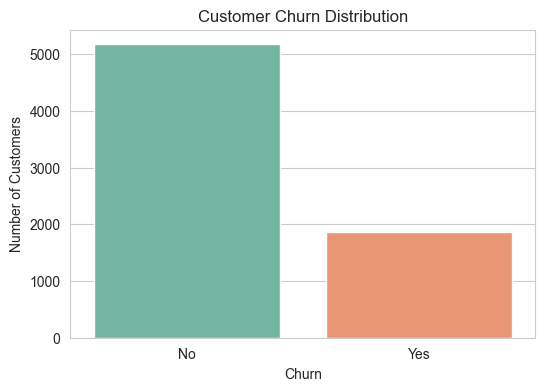

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Churn', palette='Set2')
plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.show()

In [12]:
def tenure_bucket(t):
    if t <= 12:
        return '0-12 months'
    elif t <= 24:
        return '13-24 months'
    elif t <= 48:
        return '25-48 months'
    else:
        return '49+ months'

df['TenureBucket'] = df['tenure'].apply(tenure_bucket)
df[['tenure', 'TenureBucket']].head()

,tenure,TenureBucket
0,1,0-12 months
1,34,25-48 months
2,2,0-12 months
3,45,25-48 months
4,2,0-12 months


In [13]:
churn_by_tenure = df.groupby('TenureBucket')['Churn'].value_counts(normalize=True).unstack() * 100
churn_by_tenure

Churn,No,Yes
TenureBucket,,
0-12 months,52.561757,47.438243
13-24 months,71.289062,28.710938
25-48 months,79.611041,20.388959
49+ months,90.486824,9.513176


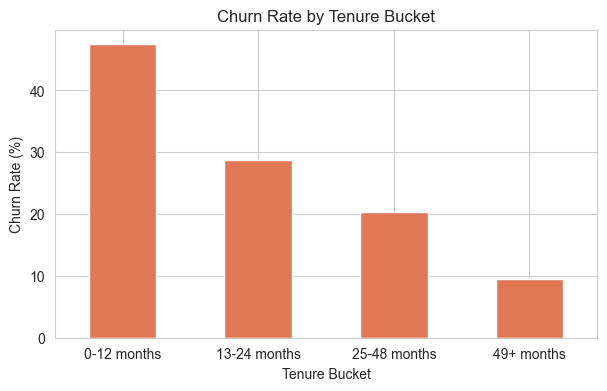

In [14]:
churn_by_tenure['Yes'].plot(kind='bar', figsize=(7,4), color='#e07856')
plt.title('Churn Rate by Tenure Bucket')
plt.xlabel('Tenure Bucket')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.show()

In [15]:
churn_by_contract = df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack() * 100
churn_by_contract

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


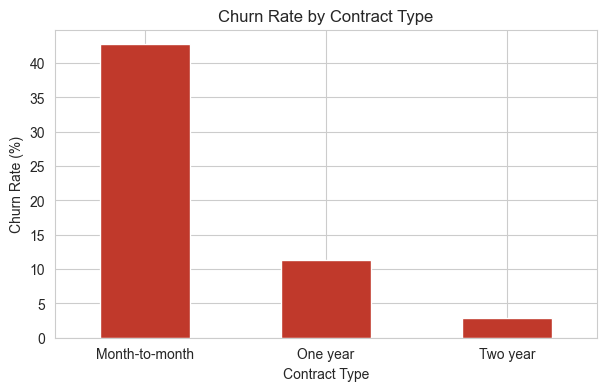

In [16]:
churn_by_contract['Yes'].plot(kind='bar', figsize=(7,4), color='#c0392b')
plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.show()

## Key Findings — Initial EDA

- **Overall churn rate:** 26.5% of customers have churned.
- **Tenure is a strong driver:** churn rate drops from 47.4% (0-12 months) to 9.5% (49+ months) — new customers are ~5x more likely to churn than long-tenured ones.
- **Contract type is the strongest driver found so far:** month-to-month customers churn at 42.7%, versus 11.3% for one-year and just 2.8% for two-year contracts — a 15x difference between the extremes.
- **Data quality note:** `TotalCharges` was loaded as text due to 11 blank-string values, all belonging to customers with 0 months tenure. Converted to numeric and filled with 0, consistent with their tenure.

In [17]:
df.to_csv('../data/processed/telco_churn_cleaned.csv', index=False)

In [18]:
import sqlite3

conn = sqlite3.connect('../data/processed/churnlens.db')
df.to_sql('customers', conn, if_exists='replace', index=False)
conn.close()

In [19]:
conn = sqlite3.connect('../data/processed/churnlens.db')

test_query = "SELECT COUNT(*) AS total_customers FROM customers"
pd.read_sql(test_query, conn)

,total_customers
0,7043


In [20]:
conn.close()

In [21]:
conn = sqlite3.connect('../data/processed/churnlens.db')

with open('../sql/02_churn_trends.sql', 'r') as f:
    query = f.read()

result = pd.read_sql(query, conn)
result.head(15)

,tenure,total_customers,churned_customers,churn_rate_pct
0,0,11,0,0.00
1,1,613,380,61.99
2,2,238,123,51.68
3,3,200,94,47.00
4,4,176,83,47.16
5,5,133,64,48.12
6,6,110,40,36.36
7,7,131,51,38.93
8,8,123,42,34.15
9,9,119,46,38.66


In [22]:
with open('../sql/03_tenure_buckets.sql', 'r') as f:
    query = f.read()

result = pd.read_sql(query, conn)
result

,tenure_bucket,total_customers,churned_customers,churn_rate_pct
0,0-12 months,2186,1037,47.44
1,13-24 months,1024,294,28.71
2,25-48 months,1594,325,20.39
3,49+ months,2239,213,9.51


In [23]:
with open('../sql/04_service_usage.sql', 'r') as f:
    query = f.read()

result = pd.read_sql(query, conn)
result

,service,has_service,total_customers,churned_customers,churn_rate_pct
0,DeviceProtection,No,3095,1211,39.13
1,DeviceProtection,Yes,2422,545,22.50
2,OnlineBackup,No,3088,1233,39.93
3,OnlineBackup,Yes,2429,523,21.53
4,OnlineSecurity,No,3498,1461,41.77
5,OnlineSecurity,Yes,2019,295,14.61
6,TechSupport,No,3473,1446,41.64
7,TechSupport,Yes,2044,310,15.17


In [24]:
with open('../sql/05_contract_payment.sql', 'r') as f:
    query = f.read()

result = pd.read_sql(query, conn)
result

,Contract,PaymentMethod,total_customers,churned_customers,churn_rate_pct
0,Month-to-month,Electronic check,1850,994,53.73
1,Month-to-month,Bank transfer (automatic),589,201,34.13
2,Month-to-month,Credit card (automatic),543,178,32.78
3,Month-to-month,Mailed check,893,282,31.58
4,One year,Electronic check,347,64,18.44
5,One year,Credit card (automatic),398,41,10.30
6,One year,Bank transfer (automatic),391,38,9.72
7,One year,Mailed check,337,23,6.82
8,Two year,Electronic check,168,13,7.74
9,Two year,Bank transfer (automatic),564,19,3.37
